notebooks modified as a sign that your new imp was seen
Using device: cuda
Created offline augmented set: 200 images in c:\Users\youssefsaad5\Downloads\deep_fake_project\dataset\own_dataset_extracted_augmented\real
Train real from data1: 12848
Train real from data2: 589
Train real from own_aug: 200
Total train images: 13637
Validation real images: 1606
Epoch [1/5] | Train Loss: 0.01376 | Val Loss: 0.00472
Epoch [2/5] | Train Loss: 0.00353 | Val Loss: 0.00287
Epoch [3/5] | Train Loss: 0.00243 | Val Loss: 0.00215
Epoch [4/5] | Train Loss: 0.00192 | Val Loss: 0.00177
Epoch [5/5] | Train Loss: 0.00160 | Val Loss: 0.00154


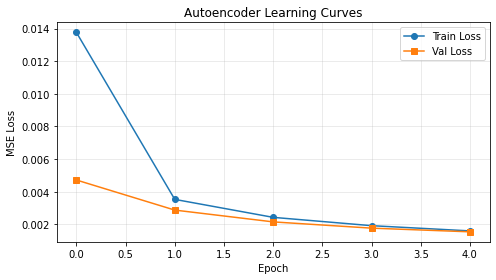

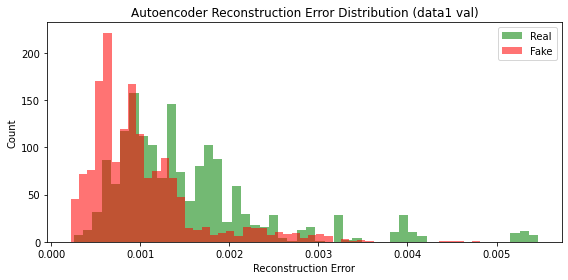

In [1]:
print("notebooks modified as a sign that your new imp was seen")
#!/usr/bin/env python
# coding: utf-8

# In[ ]:



# # Deepfake Detection System - Notebook 2
# ## Autoencoder Training (Anomaly Detection)
# 
# **Objective:**
# 1. Define a Convolutional Autoencoder architecture.
# 2. Train the model exclusively on **real images** to learn their features.
# 3. Use reconstruction error as a metric for anomaly detection (higher error = suspicious/fake).
# 4. Evaluate the autoencoder's ability to distinguish real from fake.

# In[7]:


import os
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
DATASET_PATH = r'c:\Users\youssefsaad5\Downloads\deep_fake_project\dataset'
DATA1_PATH = os.path.join(DATASET_PATH, 'data1')
DATA2_PATH = os.path.join(DATASET_PATH, 'data2')

DATA1_TRAIN_REAL = os.path.join(DATA1_PATH, 'train', 'real')
DATA1_VAL_REAL = os.path.join(DATA1_PATH, 'val', 'real')
DATA2_REAL = os.path.join(DATA2_PATH, 'real')

OWN_EXTRACTED_REAL = os.path.join(DATASET_PATH, 'own_dataset_extracted', 'real')
OWN_EXTRACTED_AUG_REAL = os.path.join(DATASET_PATH, 'own_dataset_extracted_augmented', 'real')


# ### 1. Data Loading (Real Images Only)

# In[8]:


# Same normalization policy across all real-image sources for autoencoder:
# Resize + ToTensor() => pixel values in [0, 1]
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

valid_ext = ('.png', '.jpg', '.jpeg')


def ensure_augmented_real_folder(src_dir, out_dir, target_total=200, seed=42):
    os.makedirs(out_dir, exist_ok=True)
    src_files = [f for f in glob.glob(os.path.join(src_dir, '*')) if f.lower().endswith(valid_ext)]
    if len(src_files) == 0:
        raise RuntimeError(f"No source images found in {src_dir}")

    existing = [f for f in glob.glob(os.path.join(out_dir, '*')) if f.lower().endswith(valid_ext)]
    if len(existing) == target_total:
        print(f"Augmented real folder already ready: {len(existing)} images")
        return

    for f in existing:
        os.remove(f)

    aug_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.7),
        transforms.RandomRotation(18),
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.02),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
    ])

    idx = 0
    for src in src_files:
        img = Image.open(src).convert('RGB')
        img.save(os.path.join(out_dir, f"real_{idx:04d}.jpg"), quality=95)
        idx += 1

    rng = random.Random(seed)
    while idx < target_total:
        src = rng.choice(src_files)
        img = Image.open(src).convert('RGB')
        aug = aug_tf(img)
        aug.save(os.path.join(out_dir, f"real_{idx:04d}.jpg"), quality=95)
        idx += 1

    print(f"Created offline augmented set: {idx} images in {out_dir}")


class ImagePathAutoencoderDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, img


def gather_images(folder):
    return sorted([f for f in glob.glob(os.path.join(folder, '*')) if f.lower().endswith(valid_ext)])


ensure_augmented_real_folder(OWN_EXTRACTED_REAL, OWN_EXTRACTED_AUG_REAL, target_total=200)

train_real_paths = []
train_real_paths += gather_images(DATA1_TRAIN_REAL)   # data1 training real
train_real_paths += gather_images(DATA2_REAL)         # data2 additional real
train_real_paths += gather_images(OWN_EXTRACTED_AUG_REAL)  # offline augmented own real

val_real_paths = gather_images(DATA1_VAL_REAL)  # data1 validation real

train_dataset = ImagePathAutoencoderDataset(train_real_paths, transform=transform)
val_dataset = ImagePathAutoencoderDataset(val_real_paths, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train real from data1: {len(gather_images(DATA1_TRAIN_REAL))}")
print(f"Train real from data2: {len(gather_images(DATA2_REAL))}")
print(f"Train real from own_aug: {len(gather_images(OWN_EXTRACTED_AUG_REAL))}")
print(f"Total train images: {len(train_dataset)}")
print(f"Validation real images: {len(val_dataset)}")


# ### 2. Autoencoder Architecture

# In[9]:


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 7)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)


# ### 3. Training Loop

# In[ ]:


num_epochs = 5
patience = 2
best_val_loss = float('inf')
best_state = None
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * imgs.size(0)

    epoch_train_loss = running_train / len(train_dataset)

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            outputs = model(imgs)
            val_loss = criterion(outputs, targets)
            running_val += val_loss.item() * imgs.size(0)

    epoch_val_loss = running_val / len(val_dataset)
    scheduler.step(epoch_val_loss)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.5f} | Val Loss: {epoch_val_loss:.5f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), 'autoencoder_real.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
}, 'autoencoder_real_checkpoint.pth')

plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='s', label='Val Loss')
plt.title('Autoencoder Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_learning_curves.png', dpi=150)
plt.show()


# ### 4. Evaluation & Anomaly Detection

# In[6]:


model.eval()

# Evaluate anomaly behavior on data1 validation split (real + fake)
val_full_dataset = datasets.ImageFolder(os.path.join(DATA1_PATH, 'val'), transform=transform)
val_full_loader = DataLoader(val_full_dataset, batch_size=1, shuffle=False)

errors, labels = [], []
with torch.no_grad():
    for img, label in val_full_loader:
        img = img.to(device)
        output = model(img)
        loss = criterion(output, img)
        errors.append(loss.item())
        labels.append(label.item())

errors, labels = np.array(errors), np.array(labels)
real_errors = errors[labels == val_full_dataset.class_to_idx['real']]
fake_errors = errors[labels == val_full_dataset.class_to_idx['fake']]

plt.figure(figsize=(8, 4))
plt.hist(real_errors, bins=50, alpha=0.55, label='Real', color='green')
plt.hist(fake_errors, bins=50, alpha=0.55, label='Fake', color='red')
plt.title('Autoencoder Reconstruction Error Distribution (data1 val)')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

